In [43]:
import pandas as pd

In [44]:
import matplotlib.pyplot as plt

In [45]:
df = pd.read_csv("C:/Users/ASHWI/OneDrive/Projects/bmw_global_sales_2018_2025.csv")

In [46]:
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   object 
 3   Model             3072 non-null   object 
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), object(2)
memory usage: 264.1+ KB


In [48]:
yearly_sales

,Year,Total_Units_Sold
0,2018,2765193
1,2019,2759838
2,2020,3036556
3,2021,3036564
4,2022,3083306
5,2023,3177788
6,2024,3293423
7,2025,3362777


In [49]:
df.shape

(3072, 11)

In [50]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Units_Sold', 'Avg_Price_EUR',
       'Revenue_EUR', 'BEV_Share', 'Premium_Share', 'GDP_Growth',
       'Fuel_Price_Index'],
      dtype='object')

In [51]:
df.isnull().sum()

Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64

In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
df.drop_duplicates()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.50,1.00
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.50,1.00
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.50,1.00
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.50,1.00
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.50,1.00
...,...,...,...,...,...,...,...,...,...,...,...
3067,2025,12,RestOfWorld,X5,9281,68198,632945638,0.201,5.89,2.37,1.41
3068,2025,12,RestOfWorld,X7,12785,91839,1174161615,0.203,5.89,2.37,1.41
3069,2025,12,RestOfWorld,i4,4906,63437,311221922,0.180,5.89,2.37,1.41
3070,2025,12,RestOfWorld,iX,7871,73867,581407157,0.196,5.89,2.37,1.41


In [54]:
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

In [55]:
df["Units_Sold"] = pd.to_numeric(df["Units_Sold"], errors="coerce")

In [56]:
df["Revenue_EUR"] = pd.to_numeric(df["Revenue_EUR"], errors="coerce")

In [57]:
df = df.dropna(subset=["Year", "Units_Sold"])

In [58]:
df["Year"] = df["Year"].astype(int)

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   object 
 3   Model             3072 non-null   object 
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), object(2)
memory usage: 264.1+ KB


In [60]:
yearly_sales = df.groupby("Year")["Units_Sold"].sum().reset_index()

In [61]:
yearly_sales = yearly_sales.rename(columns={"Units_Sold": "Total_Units_Sold"})

In [62]:
yearly_sales

,Year,Total_Units_Sold
0,2018,2765193
1,2019,2759838
2,2020,3036556
3,2021,3036564
4,2022,3083306
5,2023,3177788
6,2024,3293423
7,2025,3362777


In [63]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

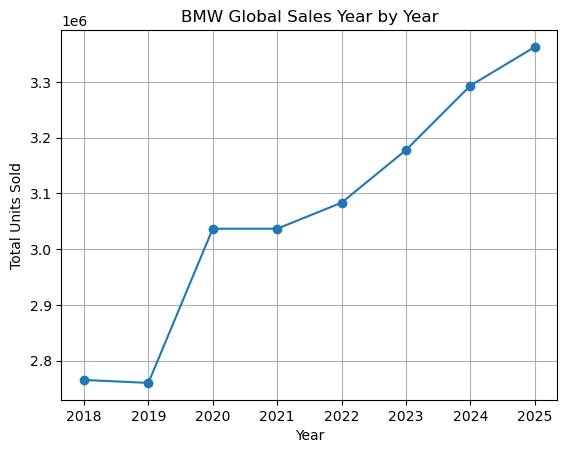

In [68]:
plt.plot(yearly_sales["Year"], yearly_sales["Total_Units_Sold"], marker="o")
plt.title("BMW Global Sales Year by Year")
plt.xlabel("Year")
plt.ylabel("Total Units Sold")
plt.grid(True)
plt.show()

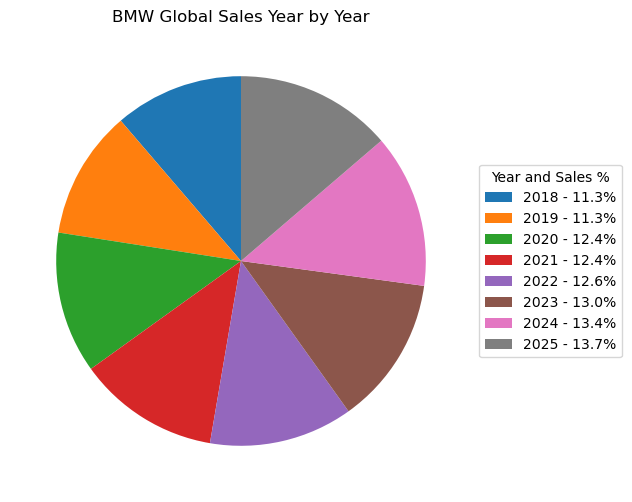

In [72]:
import matplotlib.pyplot as plt

# Calculate percentage for each year
percentages = (yearly_sales["Total_Units_Sold"] / yearly_sales["Total_Units_Sold"].sum()) * 100

# Create legend labels with year and percentage
legend_labels = [
    f"{year} - {pct:.1f}%" 
    for year, pct in zip(yearly_sales["Year"], percentages)
]

plt.figure(figsize=(6,6))

# Plot pie chart without labels
wedges, texts = plt.pie(
    yearly_sales["Total_Units_Sold"],
    startangle=90
)

# Add legend
plt.legend(
    wedges,
    legend_labels,
    title="Year and Sales %",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("BMW Global Sales Year by Year")

plt.show()

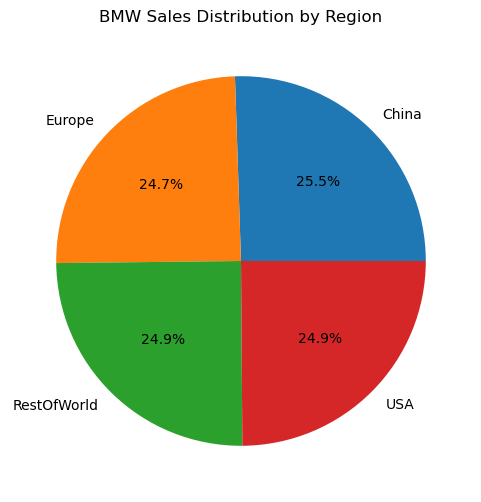

In [66]:
import matplotlib.pyplot as plt

# Group sales by region (country)
country_sales = df.groupby("Region")["Units_Sold"].sum()

# Create pie chart
plt.figure(figsize=(6,6))

plt.pie(
    country_sales,
    labels=country_sales.index,
    autopct='%1.1f%%'
)

plt.title("BMW Sales Distribution by Region")

plt.show()

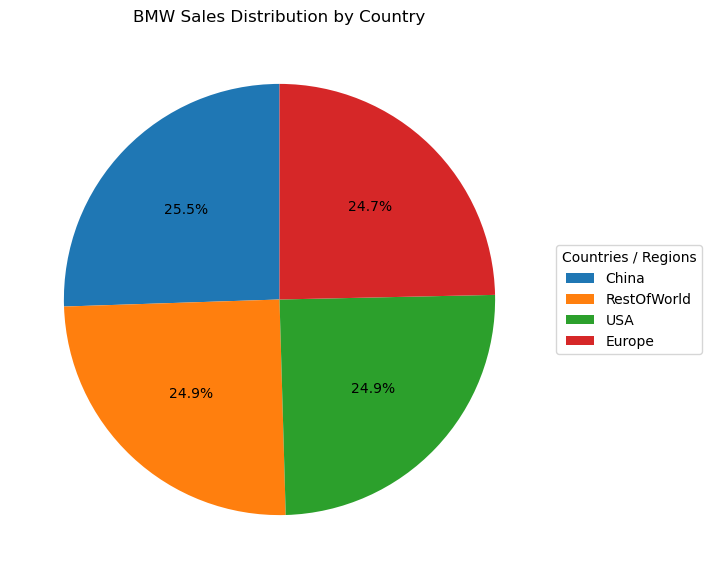

In [67]:
import matplotlib.pyplot as plt

# Group sales by region/country
country_sales = df.groupby("Region")["Units_Sold"].sum().sort_values(ascending=False)

plt.figure(figsize=(7,7))

# Plot pie chart
wedges, texts, autotexts = plt.pie(
    country_sales,
    autopct='%1.1f%%',
    startangle=90
)

# Add legend (list of countries)
plt.legend(
    wedges,
    country_sales.index,
    title="Countries / Regions",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("BMW Sales Distribution by Country")

plt.show()